In [19]:
from aqua.graphics import ConfigStyle
from aqua.util import load_yaml
import matplotlib.pyplot as plt

In [2]:
res = load_yaml('regrid_comparison_results.yaml')

In [3]:
# Build the list of values

AQUA_dict = {1: None, 2: None, 4: None, 8: None, 16: None, 32: None}
for key, value in res.items():
    if key.startswith('AQUA'):
        AQUA_dict[int(key.split('_')[1])] = value['total_time']

smmregrid_dict = {1: None, 2: None, 4: None, 8: None, 16: None, 32: None}
for key, value in res.items():
    if key.startswith('smmregrid'):
        smmregrid_dict[int(key.split('_')[1])] = value['total_time']

CDO_value = res['CDO']['total_time']

In [13]:
AQUA_dict

{1: 63.85128974914551,
 2: 50.20496280988058,
 8: 18.375070015589397,
 16: 12.905643939971924,
 64: 15.68032201131185}

In [14]:
# Normalize the values with respect to CDO, wich is the baseline
AQUA_norm = {k: CDO_value / v for k, v in AQUA_dict.items() if v is not None}
smmregrid_norm = {k: CDO_value / v for k, v in smmregrid_dict.items() if v is not None}

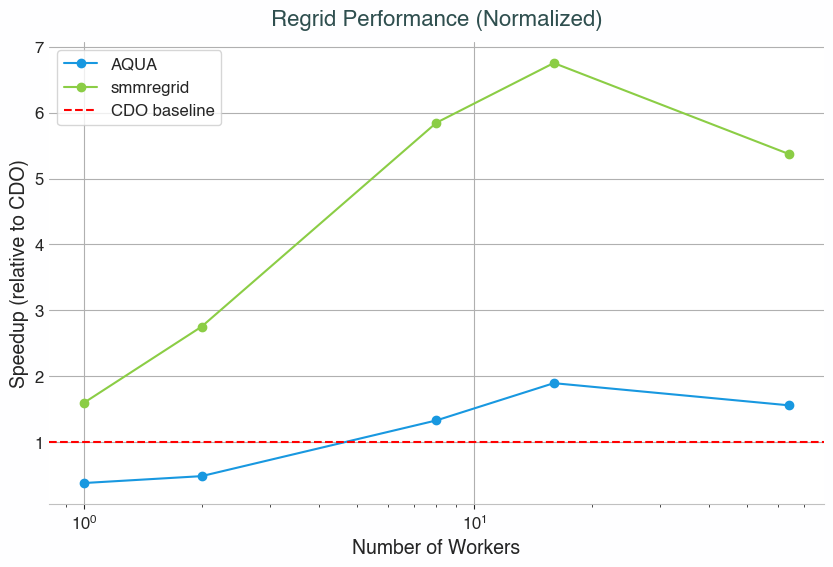

In [24]:
# Plot the normalized values
plt.figure(figsize=(10, 6))
ConfigStyle()
title_size = 16
label_size = 14
ticks_size = 12
plt.rcParams.update({
    'font.size': ticks_size,
    'axes.titlesize': title_size,
    'axes.labelsize': label_size,
    'xtick.labelsize': ticks_size,
    'ytick.labelsize': ticks_size,
})
plt.plot(list(AQUA_norm.keys()), list(AQUA_norm.values()), marker='o', label='AQUA')
plt.plot(list(smmregrid_norm.keys()), list(smmregrid_norm.values()), marker='o', label='smmregrid')
plt.title('Regrid Performance (Normalized)')
plt.xlabel('Number of Workers')
plt.ylabel('Speedup (relative to CDO)')
plt.xticks(list(AQUA_dict.keys()))
plt.grid(True)
plt.xscale('log')

# Add CDO value for comparison
if CDO_value is not None:
    plt.axhline(y=CDO_value / CDO_value, color='r', linestyle='--', label='CDO baseline')
    plt.legend()
plt.show()

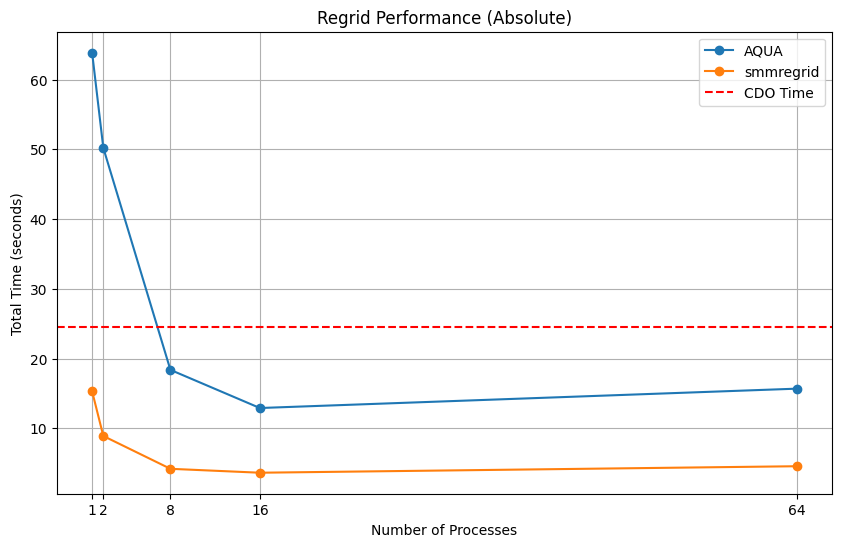

In [8]:
# Plot absolute values
plt.figure(figsize=(10, 6))
# filter list to avoid None values
AQUA_dict = {k: v for k, v in AQUA_dict.items()
                if v is not None}
smmregrid_dict = {k: v for k, v in smmregrid_dict.items()
                if v is not None}
plt.plot(list(AQUA_dict.keys()), list(AQUA_dict.values()), marker='o', label='AQUA')
plt.plot(list(smmregrid_dict.keys()), list(smmregrid_dict.values()), marker='o', label='smmregrid')
plt.title('Regrid Performance (Absolute)')
plt.xlabel('Number of Processes')
plt.ylabel('Total Time (seconds)')
plt.xticks(list(AQUA_dict.keys()))
plt.grid(True)
if CDO_value is not None:
    plt.axhline(y=float(CDO_value), color='r', linestyle='--', label='CDO Time')
    plt.legend()
plt.show()

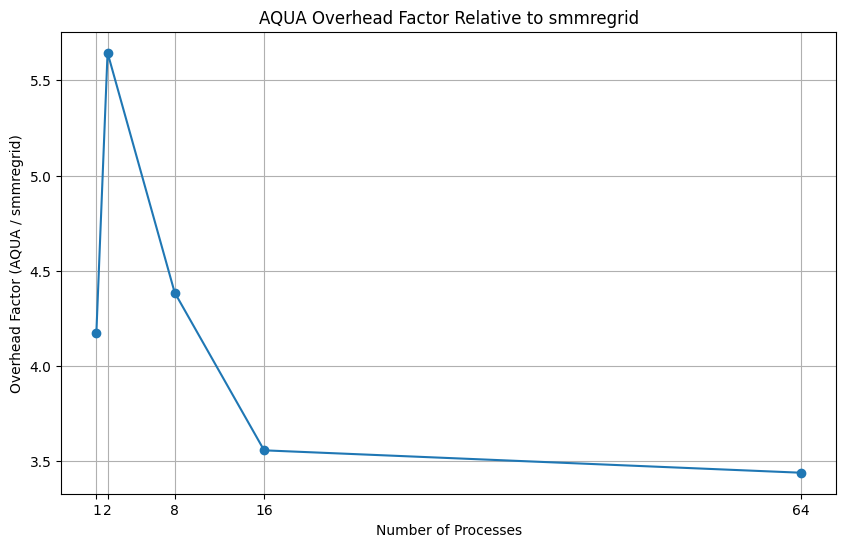

In [12]:
# Plot AQUA overhead wrt to smmregrid
plt.figure(figsize=(10, 6))
plt.plot(list(AQUA_dict.keys()), [AQUA_dict[k]/smmregrid_dict[k] for k in AQUA_dict.keys() if k in smmregrid_dict],
         marker='o', label='AQUA overhead relative to smmregrid')
plt.title('AQUA Overhead Factor Relative to smmregrid')
plt.xlabel('Number of Processes')
plt.ylabel('Overhead Factor (AQUA / smmregrid)')
plt.xticks(list(AQUA_dict.keys()))
plt.grid(True)